# State space model
Blatantly use the code from 「Pythonではじめる時系列分析入門』.

## Kalman filter
We are going to use 'UnobservedComponents' in statsmodels to construct our Kalman filter. Here is some brief introduction for the model in UnobservedComponents. (For more details see the [the statsmodels documents](https://www.statsmodels.org/dev/generated/statsmodels.tsa.statespace.structural.UnobservedComponents.html#statsmodels.tsa.statespace.structural.UnobservedComponents))

### Observation model
$$y_t = \mu_t + \gamma_t + c_t + \varepsilon_t$$

The states in this observation models are the trend ($\mu_t$), the seasonal model ($\gamma_t$) and the cyclic component ($c_t$). $\varepsilon$ is the error which is defined as irregular. The variance of the irregular will be estimated from the training data.

### Trend ($\mu_t$)
We use the dynamic linear trend which is written in the following form.

$$\mu_t = \mu_{t-1} + \beta_{t-1}+\eta_{t} \\
\beta_t = \beta_{t-1} + \zeta_{t} $$

$\eta_t$ and $\zeta_t$ is zero-mean Gaussian random variables. The *level* is the intercept term and the *trend* is the slope. Both can  dynamically vary across times.

The model name is used to specified how the trend is modeled. For example,

> 'local level':
$$y_t = \mu_t + \varepsilon_t \\ \mu_t = \mu_{t-1}+\eta_t$$
> 'random walk': $$y_t = \mu_t\\ \mu_t = \mu_{t-1} + \eta_t$$
> 'smooth trend': $$y_t = \mu_t + \varepsilon_t \\ \mu_t = \mu_{t-1} + \beta_{t-1} \\ \beta_t = \beta_{t-1} + \zeta_t$$

The output after fitting the model is in *level* and *trend* attributes.


### Seasonal components ($\gamma_t$)
There are two types of seasonal components: time domain and the frequency domain.

####Time-domain model
The time-domain seasonal model is defined as:
$$\gamma_t = -\sum_{j=1}^{s-1}\gamma_{t+1-j} + \omega_t \\
\omega_t ∼ N(0,\sigma_\omega^2)$$
The period of the season component is $s$ and is defined in the argument "seasonal = $s$". The season components sum to zero across one complete circles. $\sigma_\omega^2$ is the error term (stochastic seasonal) and can be set to zero using "stochastic_seasonal=False".

After fitting the model, this unobserved time-domain seasonal component can be found in *seasonal* attribute.

#### Frequency-domain model
The frequency-domain seasonal model is modeled as the sum of sinusoidal functions and is defined as follows.
$$\gamma_t =\sum_{j=1}^h \gamma_{j,t}\\
\gamma_{j,t+1} = \gamma_{j,t}\cos(\lambda_j) +\gamma_{j,t}^*\sin(\lambda_j)+\omega_{j,t}\\
\gamma_{j,t+1}^* = -\gamma_{j,t}^{(1)}\sin(\lambda_j) +\gamma_{j,t}^*\cos(\lambda_j)+\omega_{j,t}^*\\
\omega_{j,t}^*,\omega_{j,t}\sim N(0,\sigma_\omega^2)\\
\lambda_j=\frac{2\pi j}{s}$$
The number of sinsoidal functions used($h$) is defined as harmoncs and the default is the floor of the half of the period.

Multiple frequency-domain seasonal components can be defined in freq_seasonal as the list  "[{'period':$s$, 'harmonics':$h$}, {...}...]."
The error ($\omega_{j,t}$) in each component can bedefined in "stochastic_freq_seasonal = [..]", the lenght of the list should be the same as freq_seasonal.

After fitting the model, each unobserved frequency-domain seasonal component can be found in *freq_seasonal* attribute.

### Cycle ($c_t$)

The cycle is used to capture the effect similar to frequency-domain seasonal model but the period is much longer. It is modeled as follows.
$$c_{t+1} = \rho_c(\tilde{c}_t\cos \lambda_c t + \tilde{c}_t^*\sin \lambda_c)+\tilde\omega_t \\
c_{t+1}^* = \rho_c(-\tilde{c}_t\sin \lambda_c t + \tilde{c}_t^*\cos \lambda_c)+\tilde\omega_t^*$$

The frequency($\lambda_c$) is the parameter to be estimated by the model. $\omega_t$ and $\tilde\omega_t$ are i.i.d. Gaussian random variables. If "damped_cycle=true", the model need to estimated $\rho_c$.

The bound can be imposed to find $\lambda$ and is set in "cycle_period_bounds". The default value for bound depends on the data. If the date/time information is nor provided, the default bound is [0.5,$\infty$]. If the date/time information is available, the default bound is between 1.5 to 12 years; however, the bound depends on the frequency of the endogenous variable ($y$) so it can  differed.   

### Irregular ($\varepsilon_t$)

The irregular is the noise (error) in the observation model and is modeled as white Gaussian noise ($\varepsilon_t \sim N(0,\sigma_ɛ^2)$). However, the irregular can be modeled as AR process.
$$\varepsilon_t = \rho(L)\varepsilon_{t-1}+ \epsilon_t \\
\epsilon_t \sim N(0,\sigma_\epsilon^2)$$
The order of the AR process is defined in "autoregressive" keyword. The AR coefficient is then estimated and the estimated valued is available in *autoregressive* attribute.

### Exogeneous factors

Exogeneous factors are passed in "exog" keyword. The linear regresssion is used to find the effect of exogeneous factors. The result is available in *regression_coefficients* attributes.

## STEP 1: Import required library and data

In [ ]:
# Computation
import numpy as np
import pandas as pd
from scipy import stats

# Statistic model
import statsmodels.api as sm
import statsmodels.tsa.api as tsa

# Graph plotting
from matplotlib import pylab as plt
import matplotlib.dates as mdates
import seaborn as sns
sns.set()

# Dynamic graph
import plotly.express as px

# Display setting
np.set_printoptions(linewidth=60)
pd.set_option('display.width', 80)

from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 8, 4


### Download sample data.
We are using the daily sale data which can be affected by multipler factors including
*   flyer distribution
*   day of the week
*   bonus


In [ ]:
# Daily sale
sales_day = pd.read_csv(
    'Abc.csv',
    index_col='date',
    parse_dates=True,
    dtype='float'
)
sales_day.index.freq = 'D'

# Display the data samples
print(sales_day.head(3))
print(sales_day.tail(3))

                 sales  flyer
date                         
2000-01-01  462.387217    0.0
2000-01-02  363.262237    0.0
2000-01-03  356.648654    0.0
                 sales  flyer
date                         
2001-06-27  243.739643    0.0
2001-06-28  205.223214    0.0
2001-06-29  192.051090    0.0


### Data visualization

The dynamic graph is introduced for better visualization; however, it may not be easy when using tablet.  

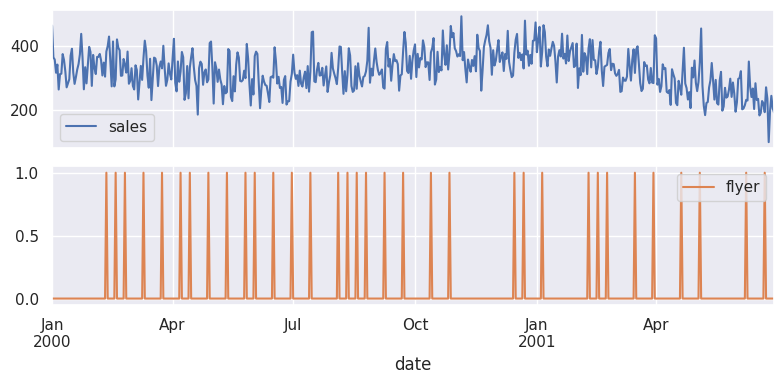

In [ ]:
# Data visualization
sales_day.plot(subplots=True)
plt.tight_layout()

In [ ]:
# Dynamic graph from plotly for better visualization.
px.line(sales_day.sales)

## STEP 2: Data exploration
This is the important step for constructing a good model. Though Kalman filter can be used to include exogeneous factors, the factors and the lags are not automatically included.

### Effect of day of the week and month

 of the week
In our data, we have the daily sale. Consumers tends to go shopping during weekend and holiday, so the date of the week should be included into the exogenous factor.

In [ ]:
# Extract the month and the day of the week information
sales_day_eda = sales_day.copy()

# Month
sales_day_eda['month'] = sales_day_eda.index.month

# Day of the week
sales_day_eda['weekday'] = sales_day_eda.index.weekday

# Show result
print(sales_day_eda.head(3))

                 sales  flyer  month  weekday
date                                         
2000-01-01  462.387217    0.0      1        5
2000-01-02  363.262237    0.0      1        6
2000-01-03  356.648654    0.0      1        0


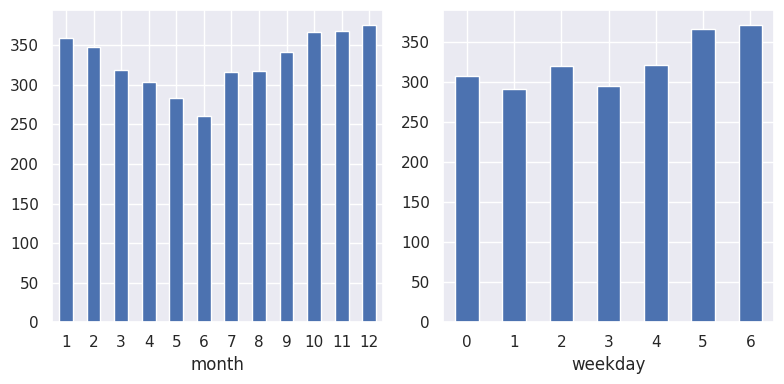

In [ ]:
fig, ax = plt.subplots(ncols=2, tight_layout=True)

# Monthly sale
sales_day_eda.groupby('month').mean()['sales'].plot(kind='bar', ax=ax[0])

# Day of the week sale
sales_day_eda.groupby('weekday').mean()['sales'].plot(kind='bar', ax=ax[1])

ax[0].xaxis.set_tick_params(rotation=0) #make the label align horizontally
ax[1].xaxis.set_tick_params(rotation=0)

### Effect of flyer

In [ ]:
# Naive investigation
print(sales_day_eda.groupby('flyer').mean()['sales'])

flyer
0.0    324.384704
1.0    320.663946
Name: sales, dtype: float64


The effect of flyer may not happen immediately. Potential buyers may go shopping one or two days later.

In [ ]:
# Take 1- and 2-day lag.
sales_day_eda['flyer_lag1'] = sales_day_eda['flyer'].shift(1).fillna(0)
sales_day_eda['flyer_lag2'] = sales_day_eda['flyer'].shift(2).fillna(0)

# Check the delayed effect of flyer
print(sales_day_eda.groupby('flyer_lag1').mean()['sales'])
print(sales_day_eda.groupby('flyer_lag2').mean()['sales'])

flyer_lag1
0.0    319.717045
1.0    390.953406
Name: sales, dtype: float64
flyer_lag2
0.0    320.347595
1.0    381.458064
Name: sales, dtype: float64


In addition to the delayed effect, we may check which day of the week the flyer were mostly distributed.

In [ ]:
print(sales_day_eda.groupby('weekday').sum()['flyer'])

weekday
0     0.0
1     0.0
2     0.0
3     0.0
4    34.0
5     0.0
6     0.0
Name: flyer, dtype: float64


#### Add the exogenous effects

#### Add delayed efffect of flyer

In [ ]:
# Add lag data
sales_day['flyer_lag1'] = sales_day['flyer'].shift(1).fillna(0)
sales_day['flyer_lag2'] = sales_day['flyer'].shift(2).fillna(0)

# Show result
print(sales_day.loc['2000-02-17':'2000-02-21'])

                 sales  flyer  flyer_lag1  flyer_lag2
date                                                 
2000-02-17  273.073148    0.0         0.0         0.0
2000-02-18  295.044613    1.0         0.0         0.0
2000-02-19  419.312910    0.0         1.0         0.0
2000-02-20  393.584443    0.0         0.0         1.0
2000-02-21  385.480800    0.0         0.0         0.0


### Effect of holiday
Consumers tend to spend more during holiday. We have to take into account of where the sale data were collected. In this case, it is Japan so we are going to use the Japanese holiday.

In [ ]:
# Import holiday information.
holiday = pd.read_csv(
    'https://www8.cao.go.jp/chosei/shukujitsu/syukujitsu.csv',
    encoding='CP932', parse_dates=True, index_col=0
)

# Show result samples.
print(holiday.head(3))

           国民の祝日・休日名称
国民の祝日・休日月日           
1955-01-01         元日
1955-01-15       成人の日
1955-03-21       春分の日


In [ ]:
# Set holiday flag.
is_holiday = sales_day.index.isin(holiday.index).astype(int)

# We should take into account of long holiday during new year.
y_st = (sales_day.index.month == 1)  & sales_day.index.day.isin([2, 3])
y_en = (sales_day.index.month == 12) & sales_day.index.day.isin([30, 31])
is_holiday = is_holiday + y_st + y_en

# Add flag to the dataframe
sales_day['holiday'] = is_holiday

# Check result
print(sales_day.head(3))

                 sales  flyer  flyer_lag1  flyer_lag2  holiday
date                                                          
2000-01-01  462.387217    0.0         0.0         0.0        1
2000-01-02  363.262237    0.0         0.0         0.0        1
2000-01-03  356.648654    0.0         0.0         0.0        1


Sunday is considerer as holiday. However, consumers tends to spend more during special holiday than Sunday. So we are going to add another flag to differentiate between Sunday and other holiday.

In [ ]:
# Add flag to differentiate between Sunday and other holiday
sales_day['sun_holiday'] = is_holiday & (sales_day.index.dayofweek == 6)

# Check result
print(sales_day.head(3))

                 sales  flyer  flyer_lag1  flyer_lag2  holiday  sun_holiday
date                                                                       
2000-01-01  462.387217    0.0         0.0         0.0        1            0
2000-01-02  363.262237    0.0         0.0         0.0        1            1
2000-01-03  356.648654    0.0         0.0         0.0        1            0


## EXPERIMENT#1: Naive Kalman filter
We are going to assume that the sale is affeced by the above exogeneous factors and has only weekly variation.


### Model setting

In [ ]:
# Smooth trend model with seasonal variation
mod_bsts_1 = tsa.UnobservedComponents(
    sales_day['sales'],                       # Observation
    level='smooth trend',                     # Trend model
    seasonal=7,                               # Time-domain seasonal components
    exog=sales_day[['holiday', 'sun_holiday', # exogeneous factor
                    'flyer', 'flyer_lag1', 'flyer_lag2']]
)

# Apply maximum likelihood method to find filter parameter
res_bsts_1 = mod_bsts_1.fit(
    method='nm',              # Nelder–Mead method
    maxiter=5000              # maximum iteration
)

Optimization terminated successfully.
         Current function value: 4.954074
         Iterations: 1665
         Function evaluations: 2464


In [ ]:
print(res_bsts_1.params)

sigma2.irregular    1237.337237
sigma2.trend           0.005019
sigma2.seasonal        0.001131
beta.holiday          54.939905
beta.sun_holiday     -89.120996
beta.flyer            -5.851373
beta.flyer_lag1       58.599146
beta.flyer_lag2       27.070692
dtype: float64


### Model validation


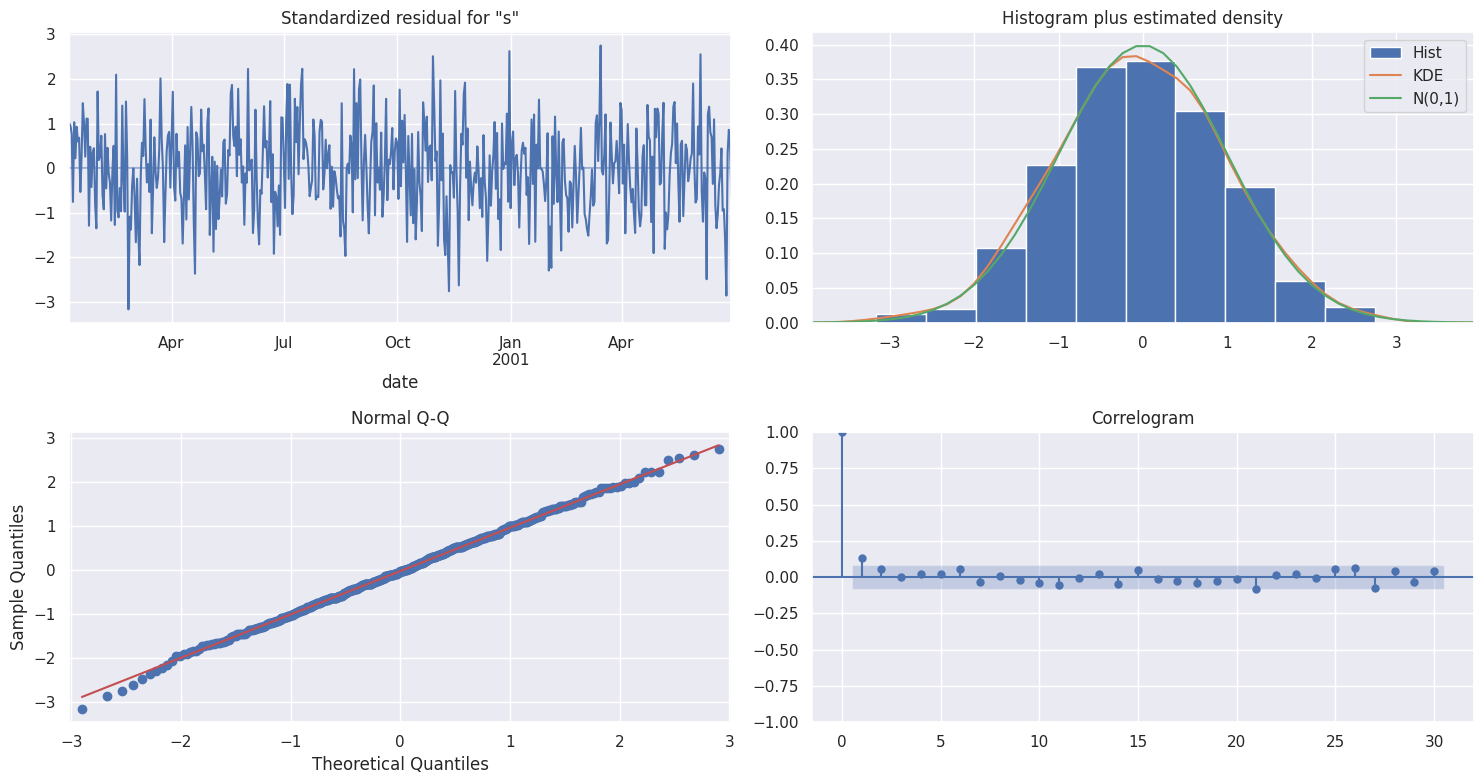

In [ ]:
# check the distribution of residual
_ = res_bsts_1.plot_diagnostics(lags=30,
        fig=plt.figure(tight_layout=True, figsize=(15, 8)))

Though the residual, histogram and normal Q-Q curve look good, the correlogram  indicated that there were still some correlation at lag 1. This indicated that the model was not optimal. Ljung-Box test was applied to further evaluate our model.

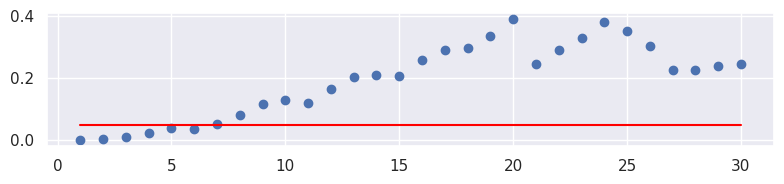

In [ ]:
res_test = res_bsts_1.test_serial_correlation(
    method='ljungbox', lags=30)

fig, ax = plt.subplots(figsize=(8, 2), tight_layout=True)
ax.scatter(np.arange(1,31), res_test[0][1])
ax.plot(np.arange(1,31), np.tile(0.05, 30), color='red')

In most cases, we will accept H1 when P-value is less than 0.05. Thus, the test confirm that the residual was not random. Not all information was used for our model.

## EXPERIMENT#2: Improved Kalman filter

Consumers tend to spend more during bonus season, thus we are going to add the effect as frequency domain model.  

The setting of frequency domain model is in the line

    freq_seasonal = [{'period': $s$, 'harmonics': $h$}]

$s$ is as the name suggests, the number of data to form one period.

$h$ is the number of sin/cos functions used to model the seasonality. If $h$ is not specified, the floor of $\frac{S}{2}$.

#### Model setting

In [ ]:
# Smooth trend model with seasonal variation
mod_bsts_2 = tsa.UnobservedComponents(
    sales_day['sales'],                       # Time series data
    level='smooth trend',                     # Trend model
    seasonal=7,                               # Time-domain seasonal component
    exog=sales_day[['holiday', 'sun_holiday', # Exogeneous factors
                    'flyer', 'flyer_lag1', 'flyer_lag2']],
    #autoregressive=2,                         # AR process to irregulars
    freq_seasonal=[{'period':365.25, 'harmonics':1}]  # Frequency-domain seasonal component
)

#  Apply maximum likelihood method to find filter parameter
res_bsts_2 = mod_bsts_2.fit(
    method='nm',              # Nelder-Mead method
    maxiter=5000              # Maximum iteration
)

Optimization terminated successfully.
         Current function value: 4.939734
         Iterations: 2580
         Function evaluations: 3727


In [ ]:
print(res_bsts_2.params)

#### Model validation

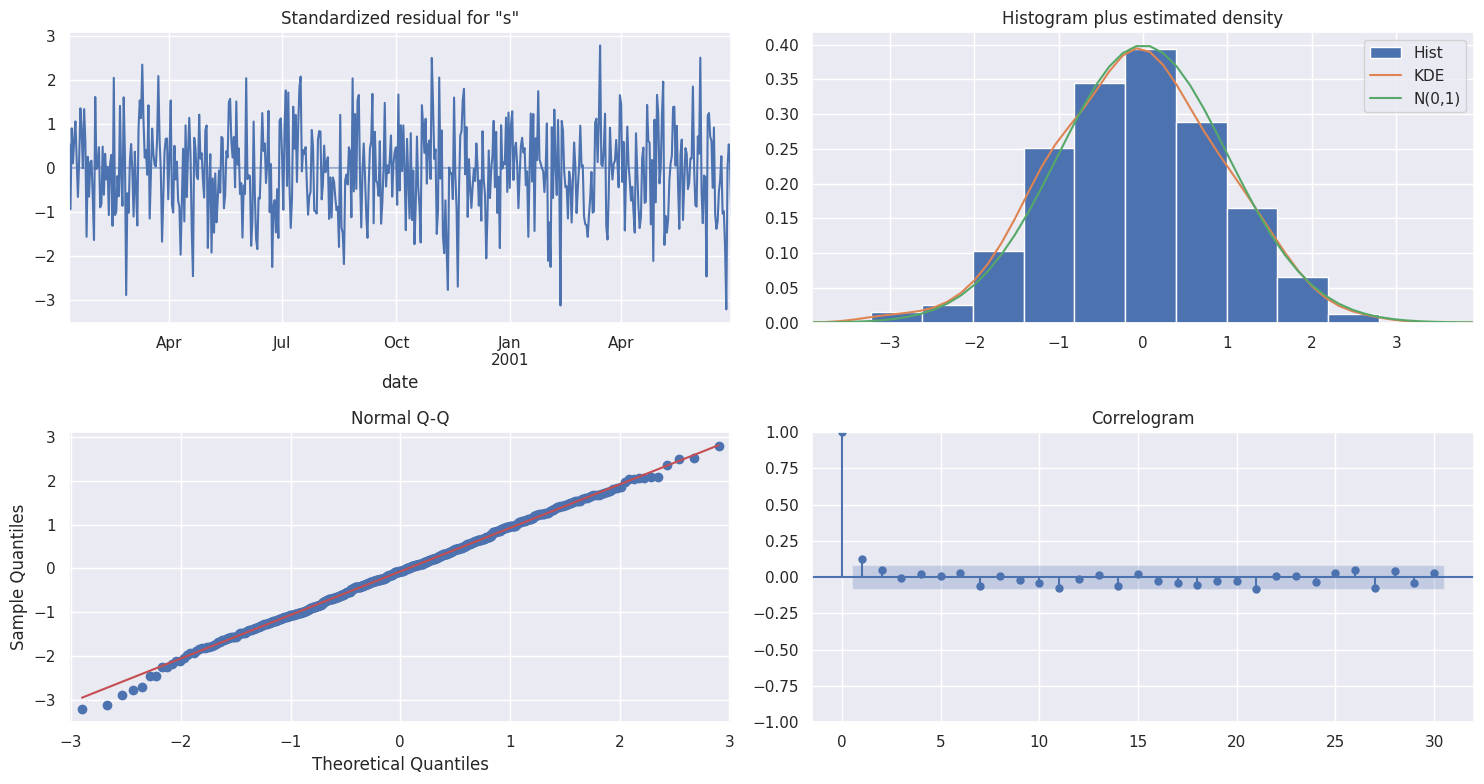

In [ ]:
# check the distribution of residual
_ = res_bsts_2.plot_diagnostics(lags=30,
        fig=plt.figure(tight_layout=True, figsize=(15, 8)))

We can see that the residual is more randomized than the naive version. We also apply Ljung-Box test to further confirm that this model is better.

In [ ]:
res_test = res_bsts_2.test_serial_correlation(
    method='ljungbox', lags=30)
fig, ax = plt.subplots(figsize=(8, 2), tight_layout=True)
ax.scatter(np.arange(1,31), res_test[0][1])
ax.plot(np.arange(1,31), np.tile(0.05, 30), color='red')

## Comparative results
Instead of comparing the exact value (level['filtered']), we are going to look at the trend (level['smoothed']) of these two models.

In [ ]:
# Comparing the mean output of the two models
plot_df = pd.DataFrame({
    'sales': sales_day['sales'],
    'mod1_level': res_bsts_1.level['smoothed'],
    'mod2_level': res_bsts_2.level['smoothed']
})

fig, ax = plt.subplots(figsize=(8, 4), tight_layout=True)

ax.plot(plot_df['sales'], color='black', label='Original')
ax.plot(plot_df['mod1_level'], linewidth=3, color='orange',
        label='Naive model')
ax.plot(plot_df['mod2_level'], linewidth=3, color='red',
        label='Improved model')

ax.set_xlabel('Date', size=14)
ax.set_ylabel('Sale', size=14)
ax.legend()

# Set lab
ax.xaxis.set_major_locator(mdates.MonthLocator([1,6])) # Tick marks at every 6 months
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y')) #set date format

In [ ]:
# Trend component
plot_df = pd.DataFrame({
    #'rawdata': sales_day['sales'],
    'Naive model': res_bsts_1.trend['smoothed'],
    'Improved model': res_bsts_2.trend['smoothed']
})

plot_df.plot()
plt.title('Trend component')